<a href="https://colab.research.google.com/github/defz-07/pengolahan-data-skripsi/blob/main/Distribusi_Jumlah_Keterlibatan_Perawat_dalam_Pengembangan_EHR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Jumlah data awal : 33
Nama kolom       : ['Apakah Anda sebagai pengguna pernah dilibatkan dalam pengembangan EHR di Instalasi Rawat Inap RSA UGM?']
Jumlah respons valid: 33

AUDIT & TRACKING LOG JAWABAN RESPONDEN PER KATEGORI

>>> KATEGORI: PERNAH TERLIBAT (8 Responden)
------------------------------------------------------------
 Baris Excel 5:
   [Teks Asli]   : ya
   [Teks Bersih] : ya

 Baris Excel 7:
   [Teks Asli]   : Ya
   [Teks Bersih] : ya

 Baris Excel 8:
   [Teks Asli]   : iya
   [Teks Bersih] : iya

 Baris Excel 15:
   [Teks Asli]   : iya
   [Teks Bersih] : iya

 Baris Excel 19:
   [Teks Asli]   : Sudah
   [Teks Bersih] : sudah

 Baris Excel 22:
   [Teks Asli]   : Ya
   [Teks Bersih] : ya

 Baris Excel 26:
   [Teks Asli]   : Pernah
   [Teks Bersih] : pernah

 Baris Excel 32:
   [Teks Asli]   : Dilibatkan
   [Teks Bersih] : dilibatkan

------------------------------------------------------------

>>> KATEGORI: BELUM/TIDAK PERNAH TERLIBAT (22 Responden)
----------------------

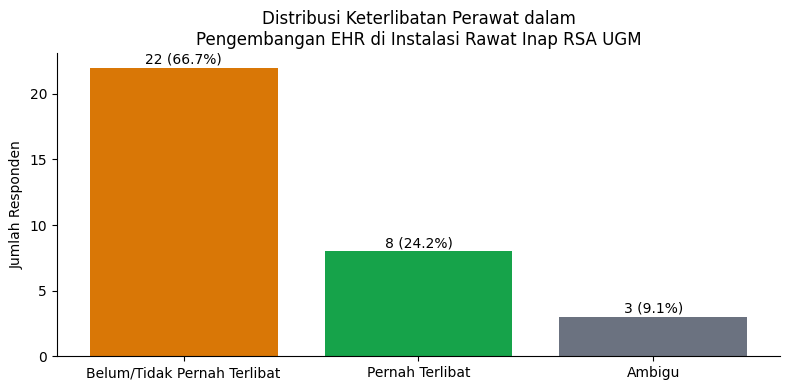

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import re

# WARNA VISUALISASI
COLOR_YES = '#16A34A'      # Hijau
COLOR_NO = '#D97706'       # Orange
COLOR_AMBIGU = '#6B7280'   # Abu-abu


df_raw = pd.read_excel('Data Kualitatif Mengenai Keterlibatan Perawat.xlsx')

print("Jumlah data awal :", len(df_raw))
print("Nama kolom       :", df_raw.columns.tolist())

response_column = df_raw.columns[0]

# MEMBERSIHKAN DATA
df = pd.DataFrame()
df['response'] = df_raw[response_column].astype(str).str.strip()

# Menyimpan indeks asli Excel (ditambah 2 karena indeks dataframe mulai dari 0
# dan baris 1 di Excel biasanya digunakan untuk nama kolom/header)
df['excel_row'] = df.index + 2

# Menghapus jawaban kosong
df = df[df['response'].str.len() > 0].reset_index(drop=True)
print("Jumlah respons valid:", len(df))

# TEXT PREPROCESSING (LOWERCASE & NORMALISASI)
normalization_dict = {
    r'\bblm\b': 'belum',
    r'\btdk\b': 'tidak',
    r'\byg\b': 'yang'
}

def preprocess_text(text):
    text = text.lower()
    for pattern, replacement in normalization_dict.items():
        text = re.sub(pattern, replacement, text)
    return text

# Menerapkan preprocessing
df['clean_response'] = df['response'].apply(preprocess_text)

# KATA KUNCI KATEGORISASI
no_patterns = [
    'belum pernah', 'tidak pernah', 'tidak terlibat', r'\bbelum\b', r'\btidak\b'
]

yes_patterns = [
    r'\bya\b', r'\biya\b', 'sudah', r'\bpernah\b', r'\bdilibatkan\b'
]

# FUNGSI KATEGORISASI (LOGIKA DIURUTKAN ULANG)
def categorize_response(text):
    # 1. Kategori Ambigu Khusus (Prioritas Utama)
    if (
        text == '-'
        or 'kurang begitu dilibatkan' in text
        or 'masukan disalurkan melalui kepala ruang' in text
    ):
        return 'Ambigu'

    # 2. Pengecekan BELUM/TIDAK PERNAH (Didahulukan)
    # Ini memastikan kalimat "belum pernah" tidak terjebak ke pola "pernah"
    for pattern in no_patterns:
        if re.search(pattern, text):
            return 'Belum/Tidak Pernah Terlibat'

    # 3. Pengecekan PERNAH/SUDAH TERLIBAT
    # Baris 26 ("pernah") dan Baris 3 ("dilibatkan") akan lolos ke sini dan sukses terkategori
    for pattern in yes_patterns:
        if re.search(pattern, text):
            return 'Pernah Terlibat'

    # 4. Jika lolos dari semua filter
    return 'Ambigu'

# Menerapkan kategorisasi
df['Kategori'] = df['clean_response'].apply(categorize_response)

# FITUR TRACKING: MENAMPILKAN DETAIL JAWABAN PER KATEGORI
print("\n" + "="*80)
print("AUDIT & TRACKING LOG JAWABAN RESPONDEN PER KATEGORI")
print("="*80)

kategori_list = ['Pernah Terlibat', 'Belum/Tidak Pernah Terlibat', 'Ambigu']

for kat in kategori_list:
    df_filter = df[df['Kategori'] == kat]
    print(f"\n>>> KATEGORI: {kat.upper()} ({len(df_filter)} Responden)")
    print("-" * 60)

    if df_filter.empty:
        print(" (Tidak ada data dalam kategori ini)")
    else:
        for idx, row in df_filter.iterrows():
            print(f" Baris Excel {row['excel_row']}:")
            print(f"   [Teks Asli]   : {row['response']}")
            print(f"   [Teks Bersih] : {row['clean_response']}")
            print()
    print("-" * 60)

# MENGHITUNG REKAPITULASI UNTUK GRAFIK
frequency_table = df['Kategori'].value_counts().reset_index()
frequency_table.columns = ['Kategori', 'Frekuensi']
frequency_table['Persentase (%)'] = (frequency_table['Frekuensi'] / len(df) * 100).round(1)

print("\n\nTabel Distribusi Akhir:")
print(frequency_table)

# MEMBUAT BAR CHART
colors = []
for category in frequency_table['Kategori']:
    if category == 'Pernah Terlibat':
        colors.append(COLOR_YES)
    elif category == 'Belum/Tidak Pernah Terlibat':
        colors.append(COLOR_NO)
    else:
        colors.append(COLOR_AMBIGU)

plt.figure(figsize=(8, 4))
bars = plt.bar(frequency_table['Kategori'], frequency_table['Frekuensi'], color=colors)

for i, bar in enumerate(bars):
    freq = frequency_table['Frekuensi'][i]
    pct = frequency_table['Persentase (%)'][i]
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        f'{freq} ({pct}%)',
        ha='center',
        fontsize=10
    )

plt.title('Distribusi Keterlibatan Perawat dalam\nPengembangan EHR di Instalasi Rawat Inap RSA UGM')
plt.ylabel('Jumlah Responden')
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()